# Model Comparison and Uncertainty Analysis

This notebook is devoted entirely to model comparison and uncertainty. 

xG itself is an estimate, not a known truth. A confidence interval quantifies uncertainty around xG from the sample(which changes slightly from model B to C when considering player attributes), such as a model coefficients, performance metrics, or potentially an xG prediction. For example, imagine Model D gives a player scoring coefficient of:

$$ \beta = 0.018,\qquad 95\%\,CI=[0.011,0.025] $$

That is much stronger evidence that player scoring ability contributes positively than:

$$ \beta = 0.018,\qquad 95\%\,CI=[-0.009,0.045] $$

because the second interval crosses zero. The precise frequentist interpretation of a 95% CI is important: if the script repeatedly sampled datasets and constructed intervals using the same procedure, approximately 95% of those intervals would contain the true parameter. It is not technically "there is a 95% probability that this particular interval contains the truth."

"Uncertainty interval" is the broader concept. It basically says: "My best estimate is X, but given uncertainty in the data/model, plausible estimates span approximately Y–Z". A model might conclude that:

$$ xG=0.31 $$

with a bootstrap 95% interval of:

[0.26, 0.36]

After coming up with my 4 models, a simple way to finihs the analysis is "Model D achieved log loss 0.XXX while Model B achieved 0.YYY. Therefore Model D is better.". However, this notebook is so see how much of the difference is simply due to sampling noise. 

A stronger analysis would bootstrap the test-set metric differences. For example:

$$ \Delta \text{LogLoss}_{D-B}=-0.006 $$

with

$$ 95\%\,CI=[-0.010,-0.002]. $$

This is better evidence that Model D's improvement is reasonably stable.

But if:

$$ 95\%\,CI=[-0.012,0.004], $$

I cannot confidently claim that Model D improves predictive performance, even if its point estimate happens to be better.

This notebook adds a component to make my overall analysis much richer than simply saying "this shot has x xG.", by answering the question: Does player-specific scoring ability add predictive information beyond shot circumstances?

The comparisons are organized as follows:

| Comparison | Question                                                    | Importance                                   |
| ---------- | ----------------------------------------------------------- | -------------------------------------------- |
| A → B      | Does shot context improve geometric xG?                     | Supporting                                   |
| A → C      | Does adding player scoring ability improve geometric xG?    | Supporting                                   |
| B → D      | Does player scoring ability add information beyond context? | Primary                                      |
| C → D      | Does your final player-ability formulation improve on C?    | Primary                                      |
| A → D      | How much better is the complete model than baseline?        | Summary                                      |





All models compared will be evaluated on the exact same test observations. Since models A and B use all shots but models C and D exclude shots belonging to players without SoFIFA ratings, then comparing their existing metrics directly is not clean. So a common evaluation dataset is created containing only shots available to all four models, and ideally use the same train/test split across them.

For each metric, this model records:
| Model | Log Loss |      95% CI | Brier | 95% CI | ROC-AUC | 95% CI |
| ----- | -------: | ----------: | ----: | -----: | ------: | -----: |
| A     |     .xxx | [.xxx,.xxx] |  .xxx |  [...] |    .xxx |  [...] |
| B     |     .xxx |       [...] |  .xxx |  [...] |    .xxx |  [...] |
| C     |     .xxx |       [...] |  .xxx |  [...] |    .xxx |  [...] |
| D     |     .xxx |       [...] |  .xxx |  [...] |    .xxx |  [...] |


# 1. Setup

This section loads the two source datasets and the saved estimators from Models A–D. The comparison is done by **feature model** (A–D) and by **estimator** (Logistic Regression, Random Forest, XGBoost, CatBoost). TabPFN is left optional because its client may require remote access.

**Important:** the saved A/B models and C/D models were originally trained on different-sized datasets. For the uncertainty analysis below, we therefore evaluate only observations that were in the original held-out test split for **both** dataset families. This avoids evaluating a saved model on observations it may have trained on.


In [1]:
from pathlib import Path
import joblib
import numpy as np
import pandas as pd

RANDOM_STATE = 42
TEST_SIZE = 0.30
N_BOOTSTRAPS = 2000

BASE = Path.home() / "Desktop/Football_Stats/xG"
DATA = BASE / "datasets/processed"
MODELS = BASE / "models"
RESULTS = BASE / "results/model_comparison"
RESULTS.mkdir(parents=True, exist_ok=True)

full_raw = pd.read_csv(DATA / "Big5_shots.csv")
attr_raw = pd.read_csv(DATA / "Big5_shots_with_player_attributes.csv")

print("Full shots:", len(full_raw))
print("Shots with player attributes:", len(attr_raw))


Full shots: 38728
Shots with player attributes: 38727


## Load saved models

These paths match the save locations in the attached notebooks.


In [2]:
from tabpfn_client import TabPFNClassifier, set_access_token

set_access_token("tabpfn_sk_yoheOhJwLpVMY1VaxzHMTnP1BptHWmc8Zcfa6_gpUIs")

In [3]:
MODEL_PATHS = {"A": {"Logistic Regression": MODELS / "Baseline Models/logistic_regressor.pkl",
                     "Random Forest": MODELS / "Baseline Models/random_forest.pkl",
                     "XGBoost": MODELS / "Baseline Models/XGBoost.pkl",
                     "CatBoost": MODELS / "Baseline Models/catBoost.pkl",
                     "TABPFN": MODELS / "Baseline Models/TABPFN.pkl"
                     }, 
                "B": {"Logistic Regression": MODELS / "xG_B/logistic_regressor.pkl",
                      "Random Forest": MODELS / "xG_B/random_forest.pkl",
                      "XGBoost": MODELS / "xG_B/XGBoost.pkl",
                      "CatBoost": MODELS / "xG_B/catBoost.pkl",
                      "TABPFN": MODELS / "xG_B/TABPFN.pkl"
                      },
                "C": {"Logistic Regression": MODELS / "xG_C/logistic_regressor.pkl",
                      "Random Forest": MODELS / "xG_C/random_forest.pkl",
                      "XGBoost": MODELS / "xG_C/XGBoost.pkl",
                      "CatBoost": MODELS / "xG_C/catBoost.pkl",
                      "TABPFN": MODELS / "xG_C/TABPFN.pkl"
                      },
                "D": {"Logistic Regression": MODELS / "xG_D/logistic_regressor.pkl",
                      "Random Forest": MODELS / "xG_D/random_forest.pkl",
                      "XGBoost": MODELS / "xG_D/XGBoost.pkl",
                      "CatBoost": MODELS / "xG_D/catBoost.pkl",
                      "TABPFN": MODELS / "xG_D/TABPFN.pkl"
                      }
                } 

models = {feature_model: {name: joblib.load(path) for name, path in paths.items()}
          for feature_model, paths in MODEL_PATHS.items() }

print("Loaded", sum(len(v) for v in models.values()), "saved estimators.")


Loaded 20 saved estimators.


# 2. Recreate the exact feature matrices used by Models A–D

The preprocessing below mirrors the attached notebooks. This matters because the saved estimators expect the same feature columns and scaling used during training.


Model A

In [4]:
from sklearn.preprocessing import MinMaxScaler

def make_A(raw):
    df = raw.copy()
    y = df["goal"]
    X = df.drop(["player", "player_id", "position", "goal", "shot_statsbomb_xg", "shot_aerial_won", "shot_first_time", 
                 "under_pressure", "shot_open_goal", "shot_follows_dribble", "goalkeeper_success_out", "half_end_early_video_end",
                 "shot_technique_Backheel", "shot_technique_Diving Header", "shot_technique_Half Volley", "shot_technique_Lob", 
                 "shot_technique_Normal", "shot_technique_Overhead Kick", "shot_technique_Volley", "shot_body_part_Head", 
                 "shot_body_part_Left Foot", "shot_body_part_Other", "shot_body_part_Right Foot", "team"], axis=1)

    scaler = MinMaxScaler()
    X[["distance", "angle"]] = scaler.fit_transform(df[["distance", "angle"]])
    X = X.drop(["location", "x", "y"], axis=1)

    return X, y

Model B

In [5]:
def make_B(raw):
    df = raw.copy()
    df.drop(["player", "player_id", "position", "location", "goalkeeper_success_out", "half_end_early_video_end", "team"], axis=1, inplace=True)
    y = df["goal"]
    X = df.drop(["goal", "shot_statsbomb_xg", "x", "y"], axis=1)
    
    return X, y


Data preprocessing for models C and D

In [6]:
def prepare_player_data(raw):
    shots = raw.copy()
    cols = ["location", "player_name_norm", "sofifa_club", "sofifa_position", "sofifa_id", "match_method", "attacking_heading_accuracy",
            "preferred_foot", "weak_foot", "team", "position", "player", "player_id", "goalkeeper_success_out", "half_end_early_video_end",
            "statsbomb_name", "statsbomb_name_norm", "short_name", "long_name", "player_positions", "club_name"]
    shots.drop(columns=cols, inplace=True)

    scaler = MinMaxScaler()
    shots[["distance", "angle", "shooting"]] = scaler.fit_transform(shots[["distance", "angle", "shooting"]])
    
    return shots

In [7]:
def make_C(raw):
    shots = prepare_player_data(raw)
    y = shots["goal"]
    X = shots.drop(["goal", "shot_statsbomb_xg"], axis=1)
    X.drop(columns=["shot_technique_Backheel", "shot_technique_Diving Header", "shot_technique_Half Volley", "shot_body_part_Other", 
                    "shot_technique_Lob", "shot_technique_Normal", "shot_technique_Overhead Kick", "shot_technique_Volley",
                    "shot_follows_dribble", "shot_aerial_won", "shot_first_time", "under_pressure", "shot_open_goal", "shot_body_part_Head", 
                    "shot_body_part_Left Foot", "shot_body_part_Right Foot", "x", "y"], inplace=True)
    
    return X, y

In [8]:
def make_D(raw):
    shots = prepare_player_data(raw)
    y = shots["goal"]
    X = shots.drop(["goal", "shot_statsbomb_xg", "x", "y"], axis=1)

    return X, y

Creating datasets for each model

In [9]:
feature_sets = {"A": make_A(full_raw), 
                "B": make_B(full_raw),
                "C": make_C(attr_raw),
                "D": make_D(attr_raw) }

for name, (X, y) in feature_sets.items():
    print(f"Model {name}: X={X.shape}, y={y.shape}")

Model A: X=(38728, 6), y=(38728,)
Model B: X=(38728, 22), y=(38728,)
Model C: X=(38727, 7), y=(38727,)
Model D: X=(38727, 23), y=(38727,)


# 3. Build one genuinely held-out comparison set

A/B were split from `Big5_shots.csv`; C/D were split from the smaller player-attribute dataset. We reconstruct both original splits and keep their intersection. The row signature links the enriched rows back to their original StatsBomb shot rows.

If the assertions fail, stop here rather than forcing the comparison: it means the enriched CSV no longer preserves a one-to-one correspondence with the original shots.


In [10]:
# Build a stable row signature from the original StatsBomb columns.
# cumcount handles the unlikely case of completely duplicated rows.
from sklearn.model_selection import train_test_split


key_cols = list(full_raw.columns)
missing_key_cols = [c for c in key_cols if c not in attr_raw.columns]
assert not missing_key_cols, f"Enriched dataset is missing original columns: {missing_key_cols}"

In [11]:
def add_row_key(df, cols):
    out = df.copy()
    base_hash = pd.util.hash_pandas_object(out[cols], index=False).astype(str)
    duplicate_number = base_hash.groupby(base_hash).cumcount().astype(str)
    out["row_key"] = base_hash + "_" + duplicate_number

    return out

full_keyed = add_row_key(full_raw, key_cols)
attr_keyed = add_row_key(attr_raw, key_cols)

assert full_keyed["row_key"].is_unique
assert attr_keyed["row_key"].is_unique

player_attributes = {'attacking_heading_accuracy', 'club_name', 'long_name', 'match_method', 'player_name_norm', 'player_positions',
                     'preferred_foot', 'shooting', 'short_name', 'sofifa_club', 'sofifa_id', 'sofifa_position', 'statsbomb_name',
                     'statsbomb_name_norm', 'weak_foot'}

if set(attr_raw.columns) - set(full_raw.columns) != player_attributes:
    warning = "\nCheck to make sure they are the sofifa features and not missing key columns that is causing the mismatch."
    assert set(attr_keyed["row_key"]).issubset(set(full_keyed["row_key"])), f"Some rows in the attributes dataset are not present in the original dataset. {warning}"

In [12]:
# set(attr_raw.columns) - set(full_raw.columns)

In [13]:
# Recreate the original 70/30 split membership using row positions.
full_positions = np.arange(len(full_raw))
_, full_test_pos = train_test_split(full_positions, test_size=TEST_SIZE, random_state=RANDOM_STATE)

attr_positions = np.arange(len(attr_raw))
_, attr_test_pos = train_test_split(attr_positions, test_size=TEST_SIZE, random_state=RANDOM_STATE)

full_test_keys = set(full_keyed.iloc[full_test_pos]["row_key"])
attr_test_keys = set(attr_keyed.iloc[attr_test_pos]["row_key"])

# Find common test keys for hold out set
common_test_keys = full_test_keys & attr_test_keys

print("A/B original test rows:", len(full_test_keys))
print("C/D original test rows:", len(attr_test_keys))
print("Common held-out rows:", len(common_test_keys))

assert len(common_test_keys) > 0, "No common held-out observations were found."

A/B original test rows: 11619
C/D original test rows: 11619
Common held-out rows: 8302


# 4. Generate predictions from every saved model

This produces the simple comparison table requested: Log Loss, ROC-AUC and Brier Score. Because each A–D notebook saved several estimator families, the table keeps estimator type explicit rather than mixing a feature-set comparison with an algorithm comparison.


In [14]:
# Map row keys back to row positions for each source dataset.
full_key_to_pos = pd.Series(full_keyed.index, index=full_keyed["row_key"])
attr_key_to_pos = pd.Series(attr_keyed.index, index=attr_keyed["row_key"])

# Use one fixed order for paired evaluation.
common_keys = sorted(common_test_keys)

prediction_frames = []
metric_rows = []

In [15]:
from sklearn.metrics import log_loss, roc_auc_score, brier_score_loss

for feature_model in ["A", "B", "C", "D"]:
    X, y = feature_sets[feature_model]

    if feature_model in ["A", "B"]:
        positions = full_key_to_pos.loc[common_keys].to_numpy()
    else:
        positions = attr_key_to_pos.loc[common_keys].to_numpy()

    X_common = X.iloc[positions].copy()
    y_common = y.iloc[positions].to_numpy()

    for estimator_name, estimator in models[feature_model].items():
        # Saved sklearn/xgboost models usually expose their training feature order.
        if hasattr(estimator, "feature_names_in_"):
            expected = list(estimator.feature_names_in_)
            missing = [c for c in expected if c not in X_common.columns]
            assert not missing, f"Model {feature_model} / {estimator_name} missing features: {missing}"
            X_eval = X_common[expected]
        else:
            X_eval = X_common

        proba = estimator.predict_proba(X_eval)[:, 1]

        metric_rows.append({
            "Model": feature_model,
            "Estimator": estimator_name,
            "N": len(y_common),
            "Log Loss": log_loss(y_common, proba),
            "ROC_AUC": roc_auc_score(y_common, proba),
            "Brier Score": brier_score_loss(y_common, proba),
        })

        prediction_frames.append(pd.DataFrame({
            "row_key": common_keys,
            "y_true": y_common,
            "Model": feature_model,
            "Estimator": estimator_name,
            "xG": proba,
        }))

metrics_table = pd.DataFrame(metric_rows).sort_values(["Estimator", "Model"])
predictions = pd.concat(prediction_frames, ignore_index=True)

metrics_table.round(4)


00:12 Predicting... Done!
00:07 Predicting... Done!
00:06 Predicting... Done!
00:07 Predicting... Done!


,Model,Estimator,N,Log Loss,ROC_AUC,Brier Score
3,A,CatBoost,8302,0.2926,0.7567,0.0840
8,B,CatBoost,8302,0.2775,0.7924,0.0793
13,C,CatBoost,8302,0.2894,0.7677,0.0832
18,D,CatBoost,8302,0.2772,0.7935,0.0793
0,A,Logistic Regression,8302,0.2947,0.7541,0.0844
5,B,Logistic Regression,8302,0.2784,0.7890,0.0795
10,C,Logistic Regression,8302,0.2916,0.7631,0.0836
15,D,Logistic Regression,8302,0.2775,0.7926,0.0793
1,A,Random Forest,8302,0.2930,0.7575,0.0842
6,B,Random Forest,8302,0.2804,0.7907,0.0802


In [16]:
# Compact view: one estimator at a time.
# PRIMARY_ESTIMATOR = "Logistic Regression"  # change if desired

# metrics_table.loc[metrics_table["Estimator"] == PRIMARY_ESTIMATOR,
#                   ["Model", "N", "Log Loss", "ROC_AUC", "Brier Score"]].set_index("Model").round(4)


from IPython.display import display

for model_name in ["A", "B", "C", "D"]:

    print(f"\nModel {model_name}")

    model_table = (
        metrics_table
        .loc[
            metrics_table["Model"] == model_name,
            [
                "Estimator",
                "N",
                "Log Loss",
                "ROC_AUC",
                "Brier Score"
            ]
        ]
        .set_index("Estimator")
        .round(4)
    )

    display(model_table)


Model A


,N,Log Loss,ROC_AUC,Brier Score
Estimator,,,,
CatBoost,8302,0.2926,0.7567,0.0840
Logistic Regression,8302,0.2947,0.7541,0.0844
Random Forest,8302,0.2930,0.7575,0.0842
TABPFN,8302,0.2922,0.7577,0.0839
XGBoost,8302,0.2924,0.7576,0.0840



Model B


,N,Log Loss,ROC_AUC,Brier Score
Estimator,,,,
CatBoost,8302,0.2775,0.7924,0.0793
Logistic Regression,8302,0.2784,0.7890,0.0795
Random Forest,8302,0.2804,0.7907,0.0802
TABPFN,8302,0.2756,0.7949,0.0786
XGBoost,8302,0.2767,0.7946,0.0792



Model C


,N,Log Loss,ROC_AUC,Brier Score
Estimator,,,,
CatBoost,8302,0.2894,0.7677,0.0832
Logistic Regression,8302,0.2916,0.7631,0.0836
Random Forest,8302,0.2897,0.7672,0.0832
TABPFN,8302,0.2892,0.7673,0.0831
XGBoost,8302,0.2899,0.7668,0.0833



Model D


,N,Log Loss,ROC_AUC,Brier Score
Estimator,,,,
CatBoost,8302,0.2772,0.7935,0.0793
Logistic Regression,8302,0.2775,0.7926,0.0793
Random Forest,8302,0.2794,0.7919,0.0799
TABPFN,8302,0.2744,0.7980,0.0784
XGBoost,8302,0.2765,0.7952,0.0791


# 5. Bootstrap 95% confidence intervals for each model

We bootstrap the **same held-out shots** for A–D. This is a paired bootstrap: every bootstrap replicate uses identical sampled shot indices across the four feature models. That is what makes the later B→D difference interpretable.


In [17]:
# def bootstrap_metrics(pred_df, estimator_name, n_bootstraps=2000, random_state=42):
#     wide = (pred_df[pred_df["Estimator"] == estimator_name] .pivot(index=["row_key", "y_true"], columns="Model", values="xG").reset_index())

#     y = wide["y_true"].to_numpy()
#     rng = np.random.default_rng(random_state)
#     rows = []

#     for b in range(n_bootstraps):
#         idx = rng.choice(len(wide), size=len(wide), replace=True)
#         y_b = y[idx]

#         # ROC-AUC is undefined if a bootstrap sample contains one class only.
#         if np.unique(y_b).size < 2:
#             continue

#         for model_name in ["A", "B", "C", "D"]:
#             p = wide[model_name].to_numpy()[idx]
#             rows.append({"bootstrap": b,
#                          "Model": model_name,
#                          "Log Loss": log_loss(y_b, p),
#                          "ROC_AUC": roc_auc_score(y_b, p),
#                          "Brier Score": brier_score_loss(y_b, p)})

#     return pd.DataFrame(rows), wide


In [18]:
# PRIMARY_ESTIMATOR = "Logistic Regression"  # change if desired
# bootstrap_results, paired_predictions = bootstrap_metrics(predictions, PRIMARY_ESTIMATOR, n_bootstraps=N_BOOTSTRAPS, random_state=RANDOM_STATE)

# bootstrap_results.head()

In [19]:
def bootstrap_metrics(predictions, estimator_name, n_bootstraps=2000, random_state=42):
    estimator_predictions = predictions[predictions["Estimator"] == estimator_name].copy()

    if estimator_predictions.empty:
        raise ValueError(f"No predictions found for estimator: {estimator_name}")

    paired = estimator_predictions.pivot(index="row_key", columns="Model", values="xG") # A/B/C/D predictions for the SAME shots side-by-side
    y_true = (estimator_predictions[["row_key", "y_true"]].drop_duplicates("row_key").set_index("row_key")) # Get the true outcome for each shot

    paired = paired.join(y_true)
    required_models = ["A", "B", "C", "D"] 

    paired = paired.dropna(subset=required_models + ["y_true"])

    # print(f"{estimator_name}: " 
    #     f"{len(paired):,} paired test shots")

    rng = np.random.default_rng(random_state)
    rows = []

    for b in range(n_bootstraps):
        idx = rng.choice(len(paired), size=len(paired), replace=True)
        sample = paired.iloc[idx]
        y_boot = sample["y_true"].to_numpy()

        # ROC-AUC requires both classes
        if len(np.unique(y_boot)) < 2:
            continue

        for model_name in required_models:
            pred_boot = sample[model_name].to_numpy()
            rows.append({"bootstrap": b,
                        "Model": model_name,
                        "Log Loss": log_loss(
                            y_boot,
                            pred_boot
                        ),
                        "ROC_AUC": roc_auc_score(
                            y_boot,
                            pred_boot
                        ),
                        "Brier Score": brier_score_loss(
                            y_boot,
                            pred_boot
                        )
                    })

    return pd.DataFrame(rows), paired

In [20]:
print(
    predictions
    .groupby(["Estimator", "Model"])
    .size()
    .unstack(fill_value=0)
)

Model                   A     B     C     D
Estimator                                  
CatBoost             8302  8302  8302  8302
Logistic Regression  8302  8302  8302  8302
Random Forest        8302  8302  8302  8302
TABPFN               8302  8302  8302  8302
XGBoost              8302  8302  8302  8302


In [21]:
ESTIMATORS = predictions["Estimator"].unique().tolist()

bootstrap_results_all = []
paired_predictions_all = {}

for estimator in ESTIMATORS:

    print(f"Bootstrapping {estimator}...")

    boot, paired = bootstrap_metrics(
        predictions,
        estimator,
        n_bootstraps=N_BOOTSTRAPS,
        random_state=RANDOM_STATE
    )

    boot["Estimator"] = estimator

    bootstrap_results_all.append(boot)
    paired_predictions_all[estimator] = paired

bootstrap_results = pd.concat(
    bootstrap_results_all,
    ignore_index=True
)

bootstrap_results.head()

Bootstrapping Logistic Regression...
Bootstrapping Random Forest...
Bootstrapping XGBoost...
Bootstrapping CatBoost...
Bootstrapping TABPFN...


,bootstrap,Model,Log Loss,ROC_AUC,Brier Score,Estimator
0,0,A,0.304608,0.740924,0.087393,Logistic Regression
1,0,B,0.288664,0.776422,0.082679,Logistic Regression
2,0,C,0.301123,0.750264,0.086463,Logistic Regression
3,0,D,0.286943,0.781260,0.082321,Logistic Regression
4,1,A,0.286604,0.748029,0.081463,Logistic Regression


In [22]:
# def ci_summary(boot_df):
#     rows = []
#     for model_name in ["A", "B", "C", "D"]:
#         sub = boot_df[boot_df["Model"] == model_name]
#         row = {"Model": model_name}

#         for metric in ["Log Loss", "ROC_AUC", "Brier Score"]:
#             lo, hi = np.percentile(sub[metric], [2.5, 97.5])
#             point = metrics_table.loc[
#                 (metrics_table["Model"] == model_name) &
#                 (metrics_table["Estimator"] == PRIMARY_ESTIMATOR),
#                 metric
#             ].iloc[0]
#             row[metric] = point
#             row[f"{metric} 95% CI"] = f"[{lo:.4f}, {hi:.4f}]"
#         rows.append(row)
#     return pd.DataFrame(rows)

# ci_table = ci_summary(bootstrap_results)
# ci_table.round(4)

In [23]:
def ci_summary(boot_df):
    rows = []
    for estimator in ESTIMATORS:
        for model_name in ["A", "B", "C", "D"]:
            sub = boot_df[(boot_df["Estimator"] == estimator) & (boot_df["Model"] == model_name)]

            row = {"Estimator": estimator,
                    "Model": model_name }

            for metric in ["Log Loss", "ROC_AUC", "Brier Score"]:

                # 95% bootstrap confidence interval
                lo, hi = np.percentile(sub[metric], [2.5, 97.5])

                # Original point estimate
                point = metrics_table.loc[(metrics_table["Model"] == model_name) & (metrics_table["Estimator"] == estimator), metric].iloc[0]

                row[metric] = point
                row[f"{metric} 95% CI"] = f"[{lo:.4f}, {hi:.4f}]"

            rows.append(row)

    return pd.DataFrame(rows)

ci_table = ci_summary(bootstrap_results)
ci_table.round(4)

,Estimator,Model,Log Loss,Log Loss 95% CI,ROC_AUC,ROC_AUC 95% CI,Brier Score,Brier Score 95% CI
0,Logistic Regression,A,0.2947,"[0.2804, 0.3084]",0.7541,"[0.7368, 0.7702]",0.0844,"[0.0794, 0.0891]"
1,Logistic Regression,B,0.2784,"[0.2646, 0.2922]",0.7890,"[0.7719, 0.8054]",0.0795,"[0.0748, 0.0841]"
2,Logistic Regression,C,0.2916,"[0.2775, 0.3051]",0.7631,"[0.7465, 0.7797]",0.0836,"[0.0787, 0.0883]"
3,Logistic Regression,D,0.2775,"[0.2636, 0.2910]",0.7926,"[0.7759, 0.8088]",0.0793,"[0.0747, 0.0839]"
4,Random Forest,A,0.2930,"[0.2789, 0.3066]",0.7575,"[0.7414, 0.7735]",0.0842,"[0.0793, 0.0889]"
5,Random Forest,B,0.2804,"[0.2668, 0.2935]",0.7907,"[0.7746, 0.8063]",0.0802,"[0.0755, 0.0848]"
6,Random Forest,C,0.2897,"[0.2758, 0.3033]",0.7672,"[0.7507, 0.7836]",0.0832,"[0.0784, 0.0879]"
7,Random Forest,D,0.2794,"[0.2661, 0.2923]",0.7919,"[0.7757, 0.8074]",0.0799,"[0.0753, 0.0845]"
8,XGBoost,A,0.2924,"[0.2782, 0.3063]",0.7576,"[0.7412, 0.7741]",0.0840,"[0.0791, 0.0886]"
9,XGBoost,B,0.2767,"[0.2626, 0.2901]",0.7946,"[0.7784, 0.8103]",0.0792,"[0.0746, 0.0836]"


A → B: shot context matters substantially

Adding shot-context information gives:

$$ \Delta LL=-0.01638 $$

with:

$$ 95\%CI=[-0.02022,-0.01252] $$

and ROC-AUC improves by:

$$ +0.03433 $$

with:

$$ 95\%CI=[0.02560,0.04278] $$

Neither interval crosses zero.

So shot context adds substantial predictive information beyond your baseline geometric xG model.

Also we can see that C improves over A.

$$ A: LL = .2958, AUC = .7521 $$
$$ C: LL = .2924, AUC = .7616 $$

That suggests player scoring ability alone adds information beyond your baseline features.

But $$ B: LL = .2795, AUC = .7862. $$ Meaning shot context produces a much larger improvement.

That's an interesting substantive football result: Knowing the circumstances under which a shot occurs appears substantially more predictive than knowing the shooter's FIFA scoring ability alone.

# 6. Paired uncertainty in the model improvements

For the project question, **B→D is the key comparison**: Model B contains shot circumstances, while Model D adds player-specific scoring ability. A→B is useful supporting evidence, C→D shows the value of context when player ability is present, and A→D summarizes the total progression.

For Log Loss and Brier, negative Δ means the second model is better. For ROC-AUC, positive Δ means the second model is better.


In [24]:
def paired_bootstrap_deltas(boot_df, comparisons=None):

    if comparisons is None:
        comparisons = [ ("A", "B"),  # contribution of context
                        ("A", "C"),  # contribution of player ability
                        ("B", "D"),  # player ability after context
                        ("C", "D"),  # context after player ability
                        ("A", "D")   # total improvement
                    ]

    rows = []

    for estimator in boot_df["Estimator"].unique():
        estimator_boot = boot_df[boot_df["Estimator"] == estimator].copy()

        wide = estimator_boot.pivot(index="bootstrap", columns="Model", values=["Log Loss", "ROC_AUC", "Brier Score"])
        for first, second in comparisons:
            for metric in ["Log Loss", "ROC_AUC", "Brier Score"]:
                delta = (wide[(metric, second)]- wide[(metric, first)]) # second model - first model
                lo, median, hi = np.percentile(delta.dropna(), [2.5, 50, 97.5])

                rows.append({"Estimator": estimator,
                             "Comparison": f"{first} → {second}",
                             "Metric": metric,
                             "Median Δ": median,
                             "95% CI Lower": lo,
                             "95% CI Upper": hi
                         })

    return pd.DataFrame(rows)


delta_table = paired_bootstrap_deltas(bootstrap_results)
delta_table.round(5)


,Estimator,Comparison,Metric,Median Δ,95% CI Lower,95% CI Upper
0,Logistic Regression,A → B,Log Loss,-0.01631,-0.01975,-0.01265
1,Logistic Regression,A → B,ROC_AUC,0.03495,0.02605,0.04378
2,Logistic Regression,A → B,Brier Score,-0.00487,-0.00606,-0.00368
3,Logistic Regression,A → C,Log Loss,-0.00314,-0.00449,-0.00175
4,Logistic Regression,A → C,ROC_AUC,0.00911,0.00519,0.01277
...,...,...,...,...,...,...
70,TABPFN,C → D,ROC_AUC,0.03077,0.02318,0.03809
71,TABPFN,C → D,Brier Score,-0.00469,-0.00582,-0.00356
72,TABPFN,A → D,Log Loss,-0.01779,-0.02137,-0.01403
73,TABPFN,A → D,ROC_AUC,0.04046,0.03189,0.04890


The central result: B → D

This is the research question.

For Log Loss
$$ \Delta=-0.00112 $$ $$ 95\%CI=[-0.00196,-0.00032] $$

This indicates that adding player-specific scoring ability to shot context produces a small but consistently favorable improvement in Log Loss across the bootstrap samples.

For ROC-AUC

$$ \Delta=+0.00382 $$ $$ 95\%CI=[+0.00183,+0.00589] $$

Again, the entire interval is favorable. So player scoring ability also provides a small but stable improvement in discrimination.

That is the second piece of evidence supporting the research hypothesis.

For Brier Score

$$ \Delta=-0.00016 $$

with:

$$ 95\%CI=[-0.00037,+0.00006] $$

This interval crosses zero.

So we cannot not claim a reliable Brier-score improvement.

# 7. Visualize model metrics with 95% bootstrap CIs


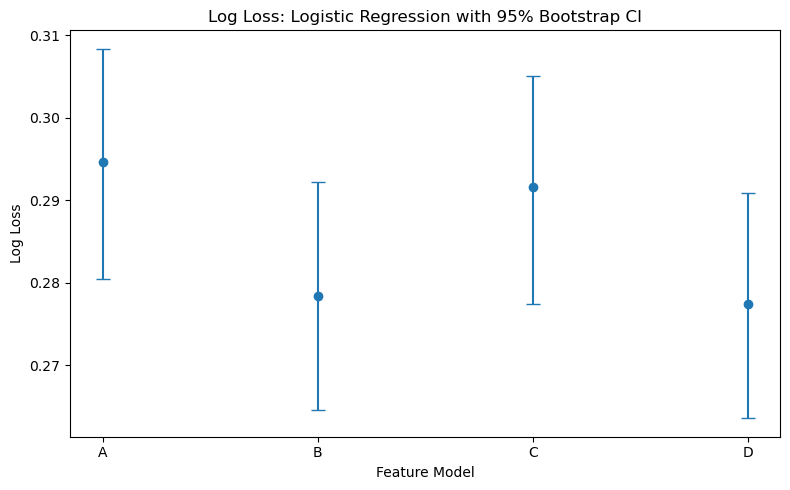

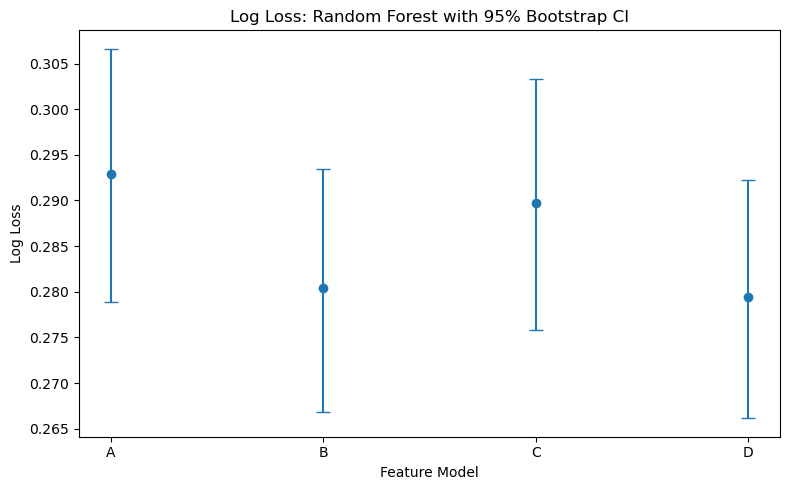

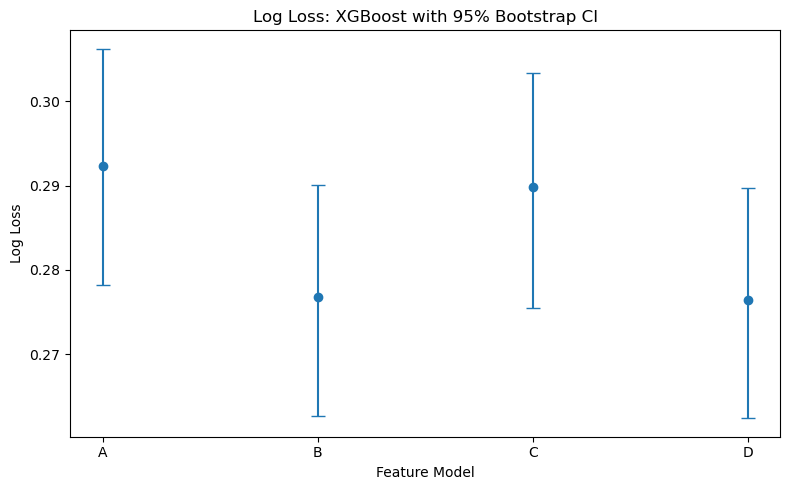

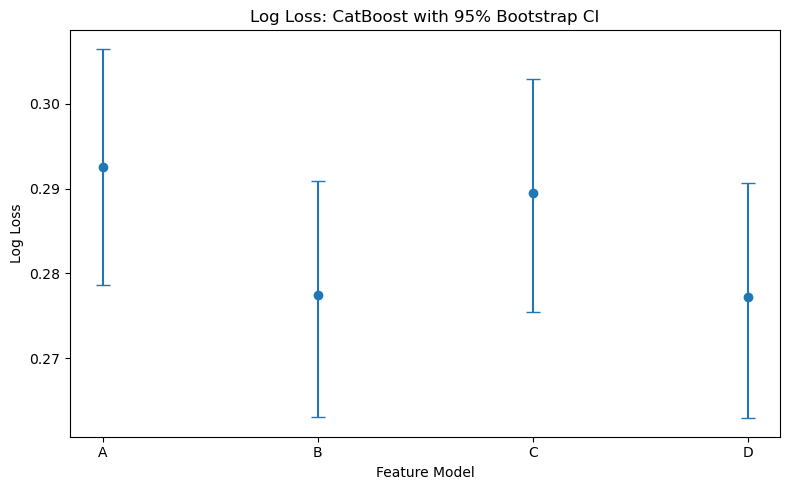

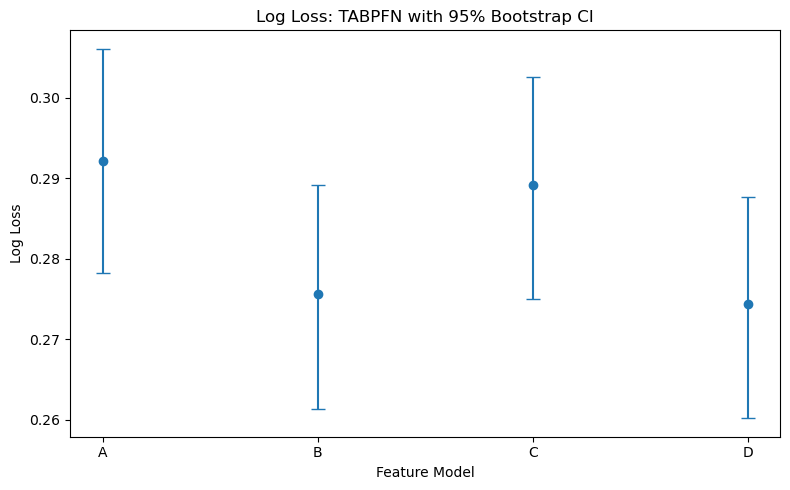

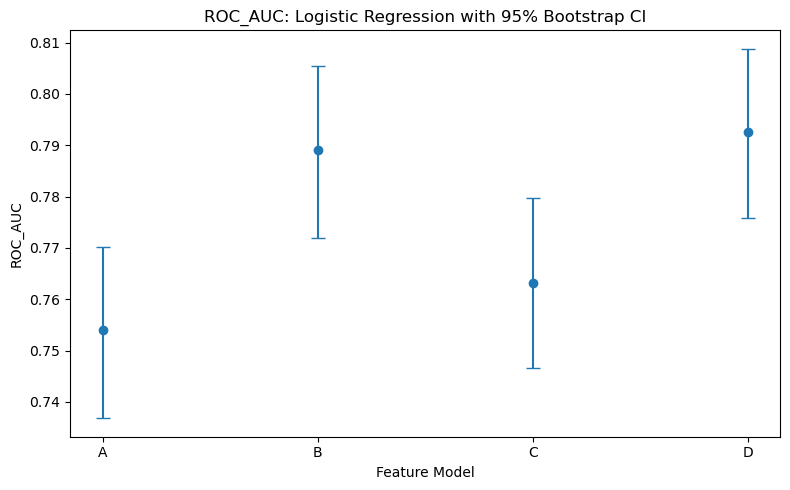

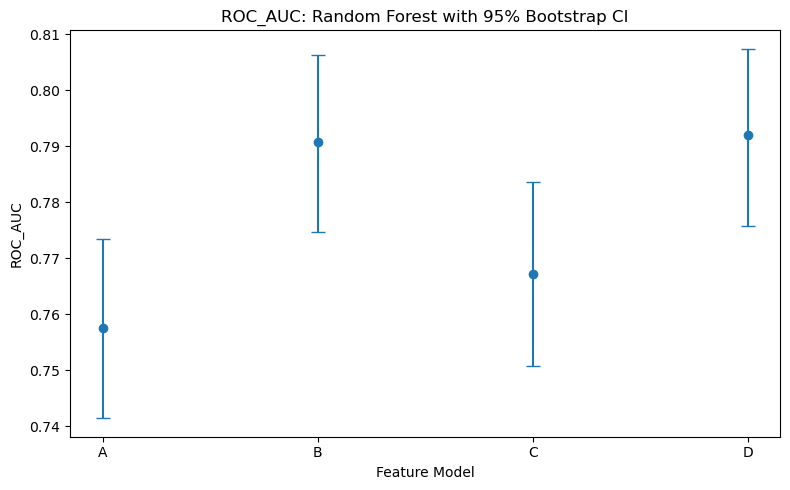

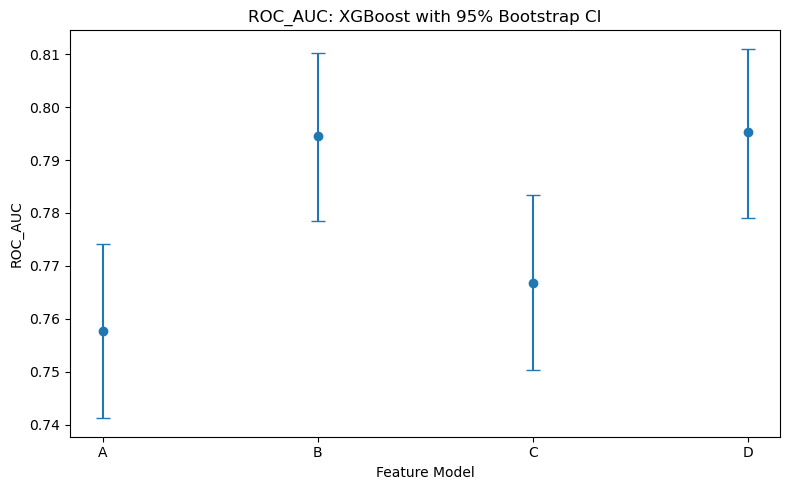

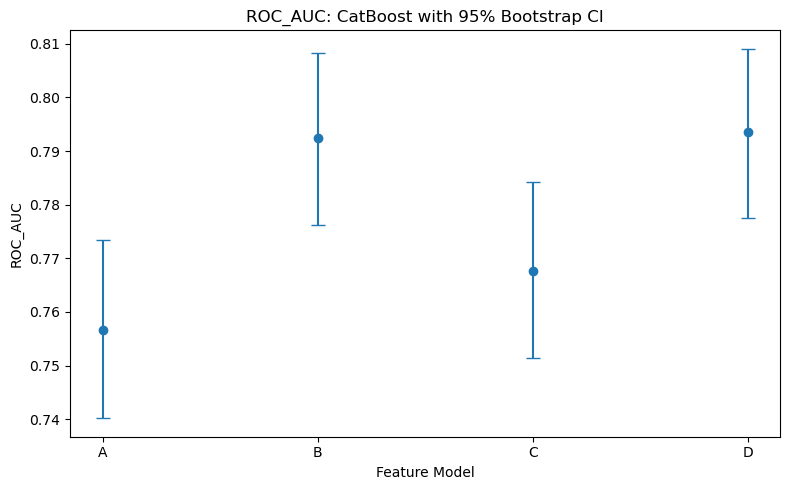

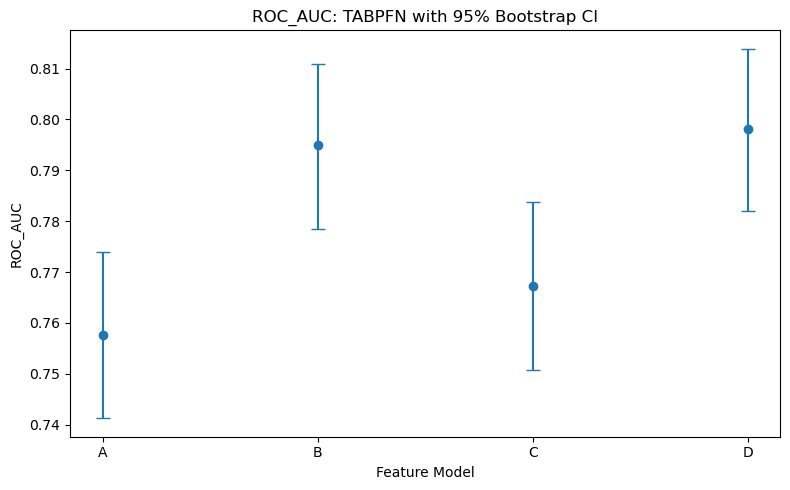

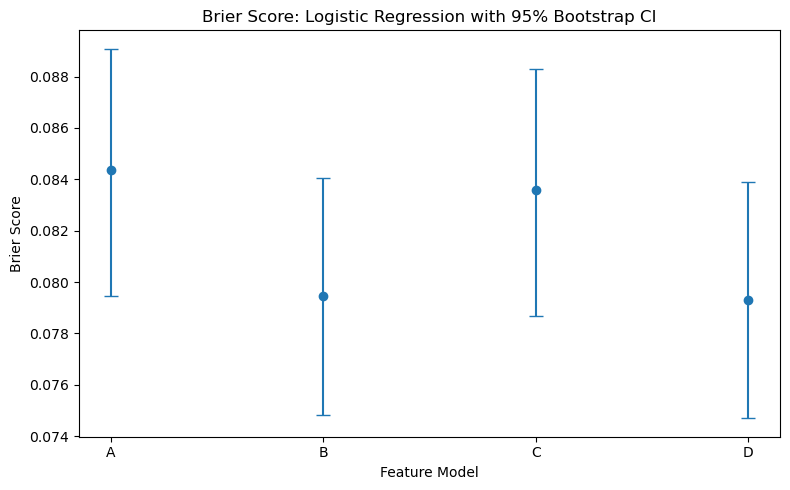

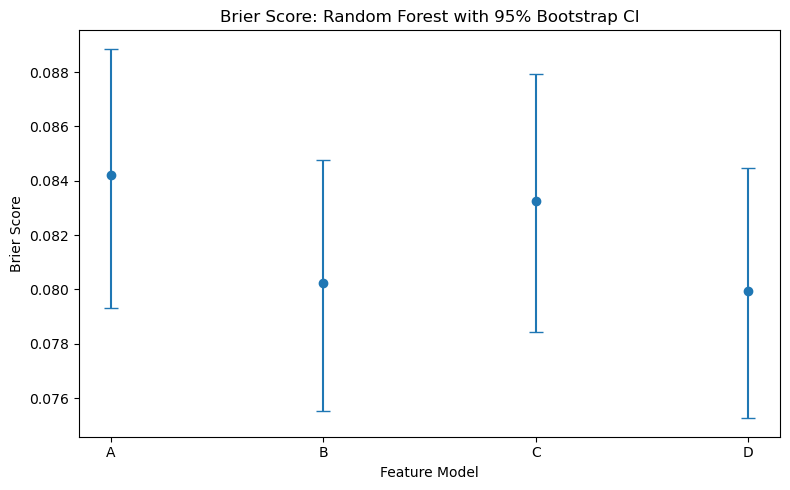

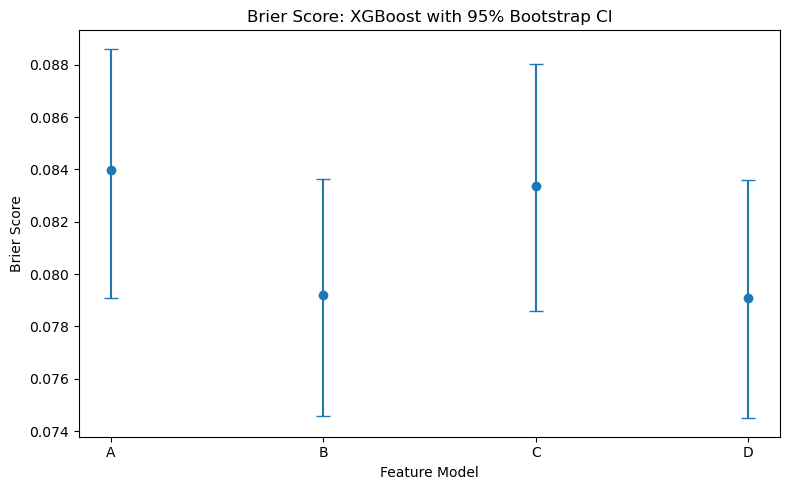

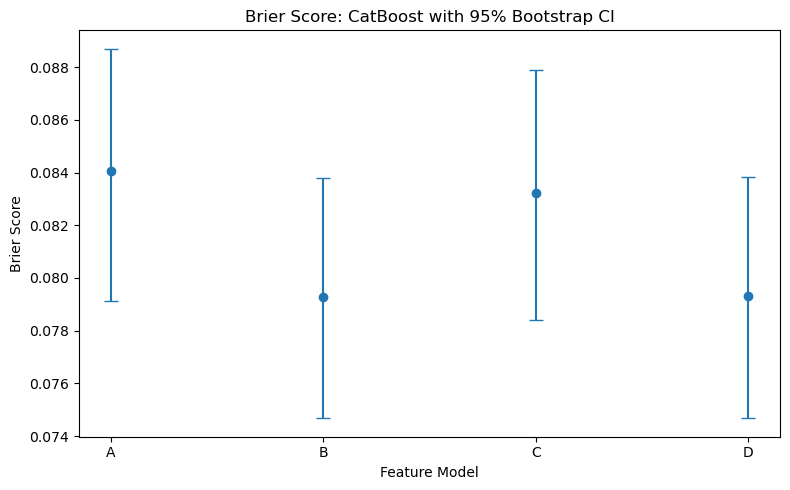

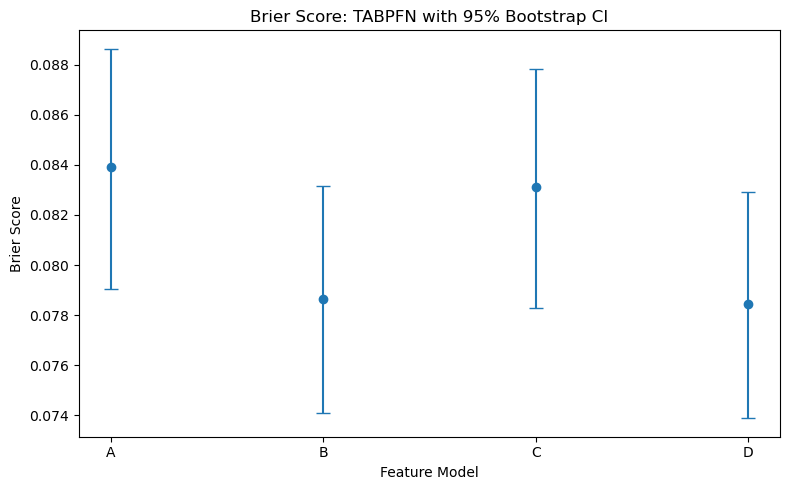

In [25]:
import matplotlib.pyplot as plt

def plot_metric_ci(metric):
    models_order = ["A", "B", "C", "D"]
    for estimator in bootstrap_results["Estimator"].unique():
        points = []
        lower_err = []
        upper_err = []

        for model_name in models_order:
            values = bootstrap_results.loc[(bootstrap_results["Estimator"] == estimator) & (bootstrap_results["Model"] == model_name), metric]

            lo, hi = np.percentile(values,[2.5, 97.5]) # 95% bootstrap confidence interval
            point = metrics_table.loc[(metrics_table["Model"] == model_name) & (metrics_table["Estimator"] == estimator), metric].iloc[0] # original point estimate
            points.append(point)
            lower_err.append(point - lo)
            upper_err.append(hi - point)

        plt.figure(figsize=(8, 5))
        plt.errorbar(models_order, points, yerr=[lower_err, upper_err], fmt="o", capsize=5)
        plt.xlabel("Feature Model")
        plt.ylabel(metric)
        plt.title(f"{metric}: {estimator} with 95% Bootstrap CI")
        plt.tight_layout()
        plt.show()


plot_metric_ci("Log Loss")
plot_metric_ci("ROC_AUC")
plot_metric_ci("Brier Score")

# 8. Visualize the primary B→D comparison

The zero line represents "no performance change." If the 95% bootstrap interval for **D − B** stays entirely on the favorable side of zero, the observed improvement is stable across bootstrap resamples of the held-out shots.


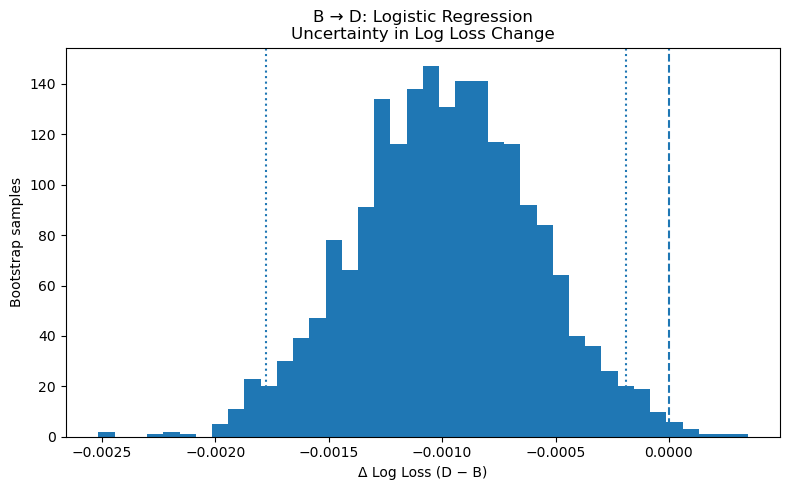

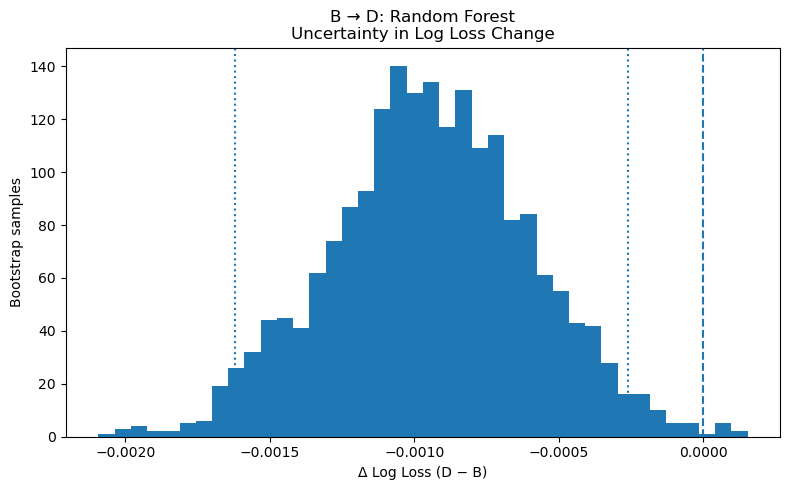

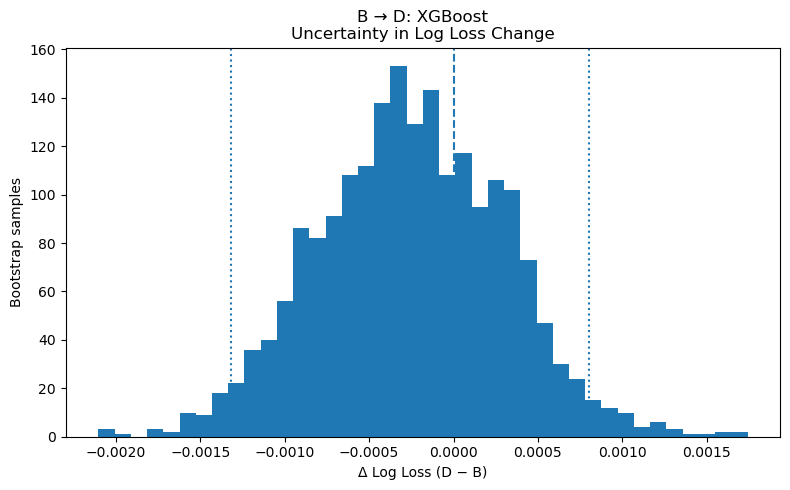

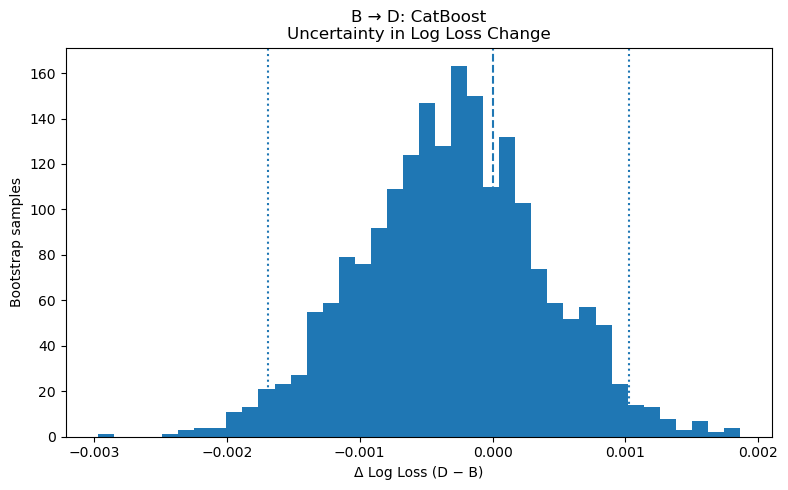

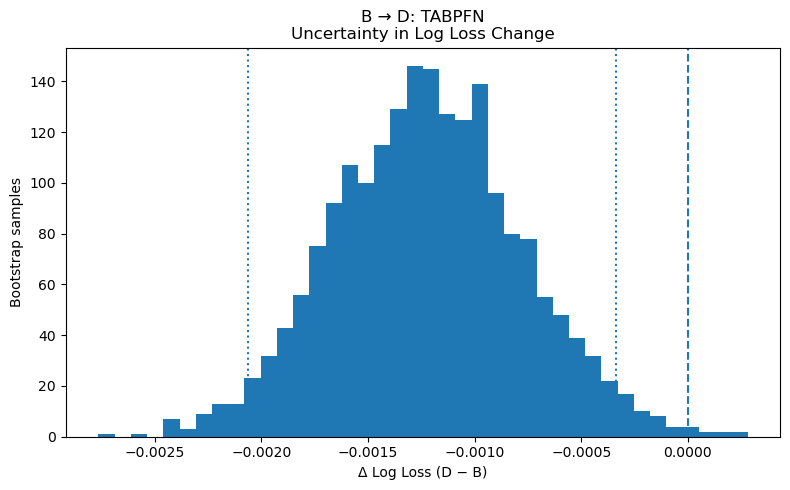

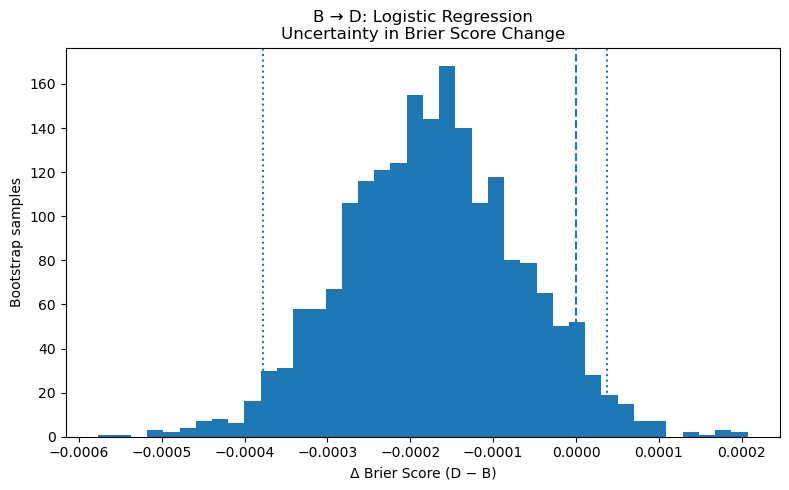

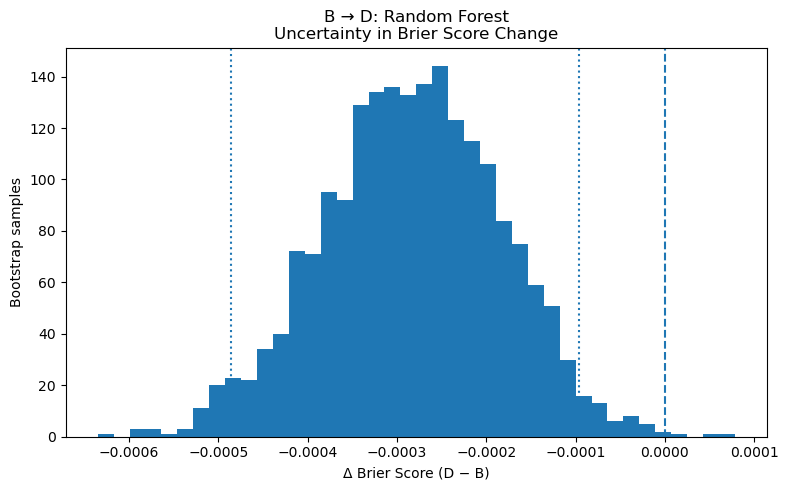

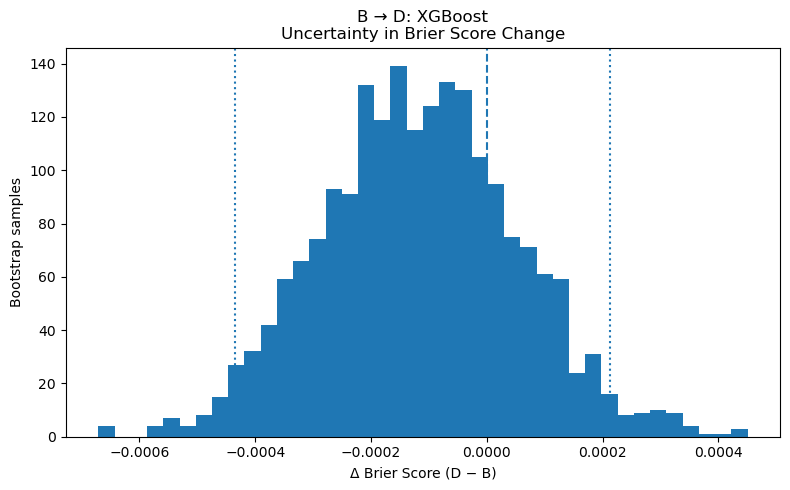

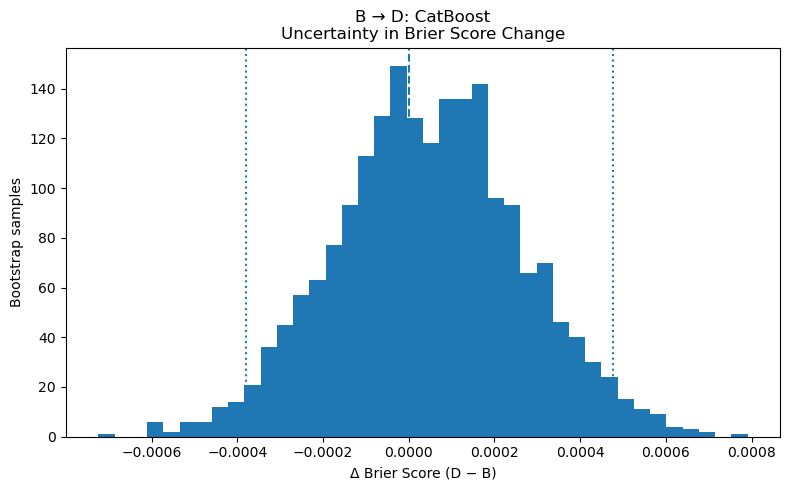

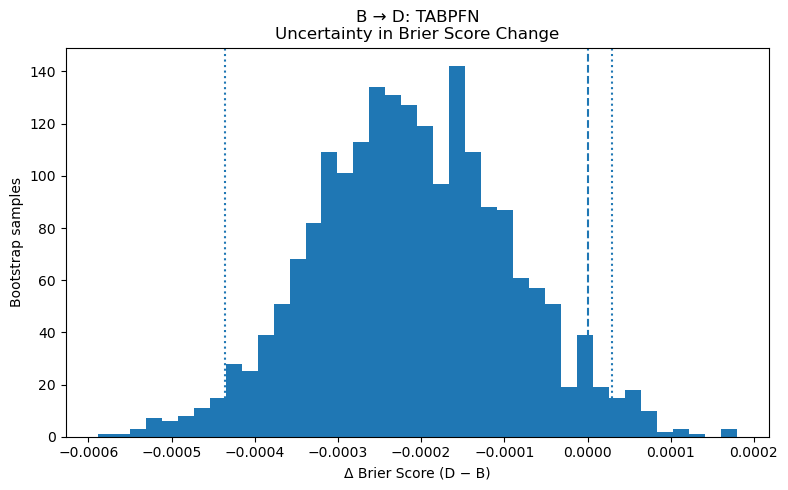

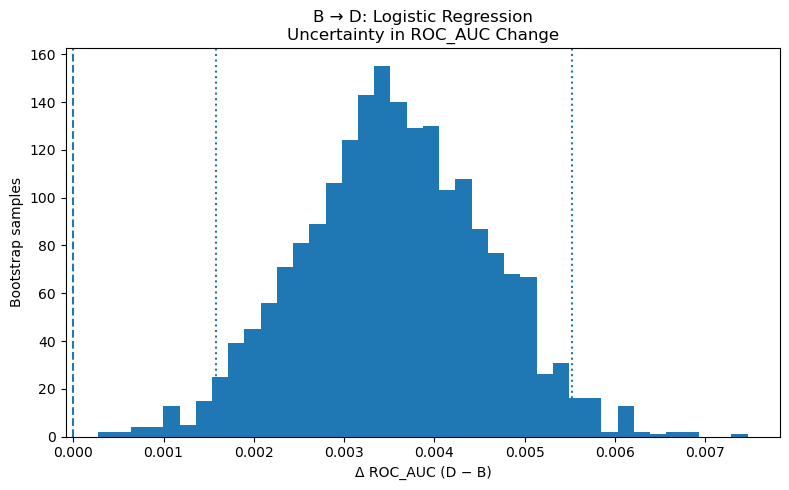

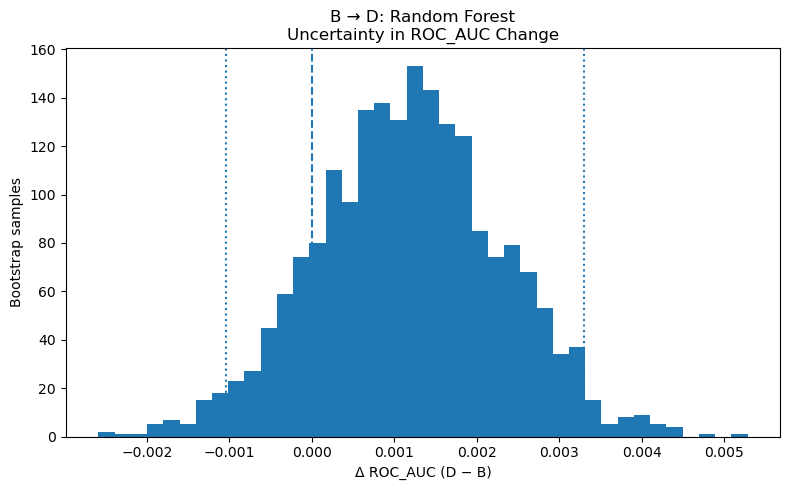

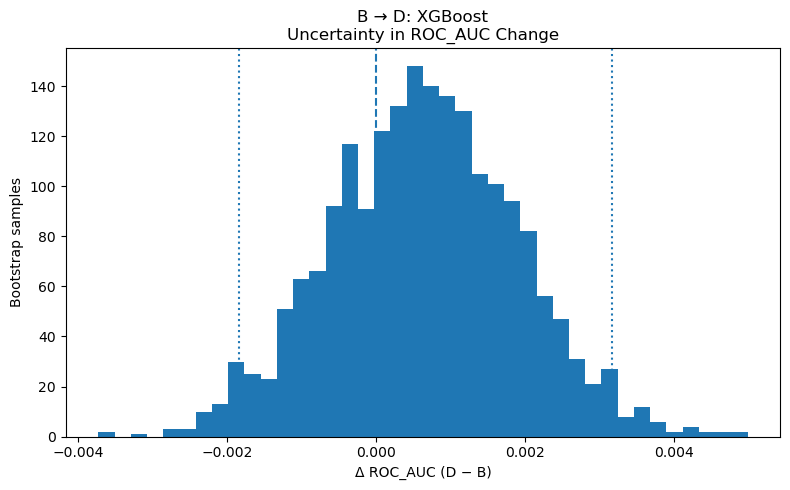

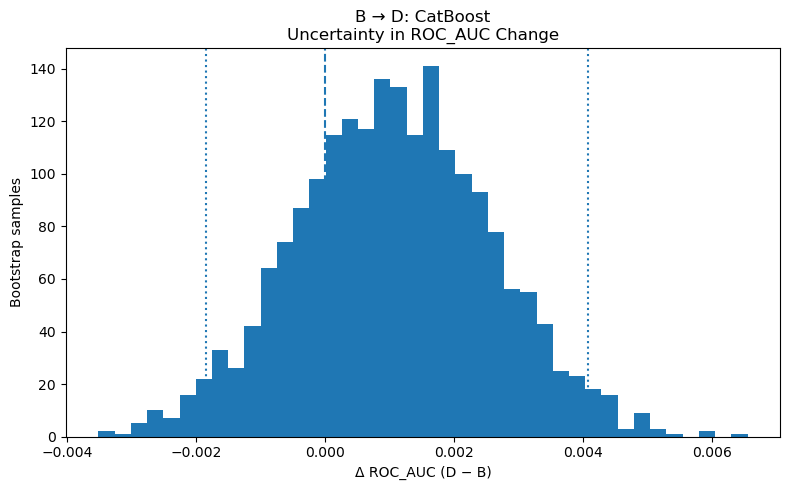

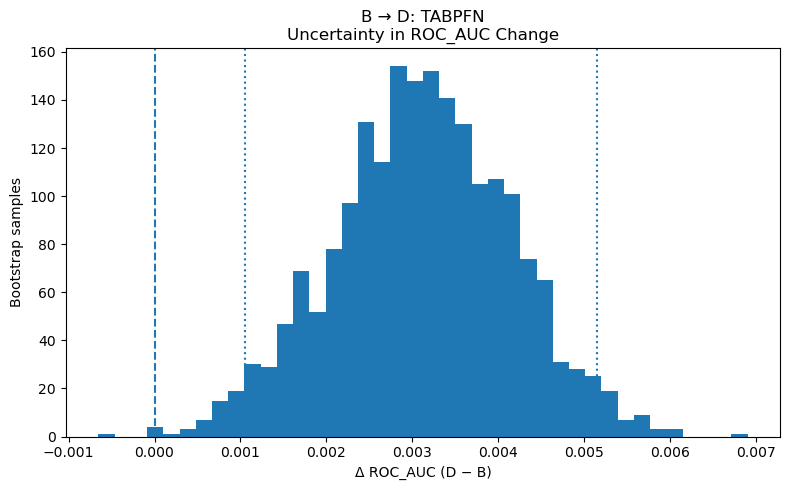

In [26]:
def plot_delta_distribution(metric, first="B", second="D"):

    for estimator in bootstrap_results["Estimator"].unique():
        estimator_boot = bootstrap_results[bootstrap_results["Estimator"] == estimator]
        wide = estimator_boot.pivot(index="bootstrap", columns="Model", values=metric)

        delta = wide[second] - wide[first]
        lo, hi = np.percentile(delta.dropna(), [2.5, 97.5]) # 95% bootstrap confidence interval

        plt.figure(figsize=(8, 5))
        plt.hist(delta.dropna(), bins=40)

        plt.axvline(0, linestyle="--") # no change 
        plt.axvline(lo, linestyle=":") # 95% CI lower bound
        plt.axvline(hi, linestyle=":") # 95% CI upper bound

        plt.xlabel(f"Δ {metric} ({second} − {first})")
        plt.ylabel("Bootstrap samples")
        plt.title(f"{first} → {second}: {estimator}\n"
                  f"Uncertainty in {metric} Change")
        plt.tight_layout()
        plt.show()

plot_delta_distribution("Log Loss")
plot_delta_distribution("Brier Score")
plot_delta_distribution("ROC_AUC")

# 9. Save analysis tables

These CSVs can be used directly when writing the results section.


In [27]:
metrics_table.to_csv(RESULTS / "model_metrics_common_test.csv", index=False)
ci_table.to_csv(RESULTS / "model_metrics_95ci.csv", index=False)
delta_table.to_csv(RESULTS / "paired_model_differences_95ci.csv", index=False)

print("Saved results to:", RESULTS)


Saved results to: /Users/nanakwamekankam/Desktop/Football_Stats/xG/results/model_comparison


# Conclusion

The results aren't saying Player ability completely changes xG prediction, they're saying: 

Most predictive information appears to come from the characteristics and circumstances of the shot itself, but player-specific scoring ability provides a small additional amount of predictive information once those circumstances are already accounted for.

The B→D result supports that statement through two metrics:

$$ Log Loss    ✓ favorable CI excluding zero $$
$$ ROC-AUC     ✓ favorable CI excluding zero $$
$$ Brier       ? CI includes zero $$

The evidence isn't uniformly strong across every measure, but it is consistent enough to be meaningful.

C → D gives another important result that supports the claim. The comparison is much larger:

$$ \Delta LL=-0.01403 $$

with:

$$ 95\%CI=[-0.01753,-0.01054] $$

and:

$$ \Delta AUC=+0.02863 $$

with:

$$ 95\%CI=[0.02048,0.03678]. $$

That means that player ability does not replace shot context. When you already know player ability (C), adding contextual information (D) still produces a substantial improvement.

Compared to adding player ability after context: 

B → D
$$ \Delta Log Loss = -0.00112 $$
$$ \Delta AUC      = +0.00382 $$

The asymmetry is striking.

Conceptually:

Added information

Baseline ──context──► B
            (LARGE)

Baseline ──player───► C
          (smaller)


B ──player──► D
     (small)

C ──context─► D
     (LARGE)

# Interpretation guide

For the central research question, report **Model B vs Model D using the same estimator family**. Do not infer significance merely because two separate model confidence intervals overlap or do not overlap; use the paired **D − B** bootstrap interval.

- **Log Loss / Brier:** lower is better; a D−B interval entirely below 0 supports improved probabilistic prediction from player scoring ability.
- **ROC-AUC:** higher is better; a D−B interval entirely above 0 supports improved discrimination.
- If the interval crosses 0, describe the point estimate but do not claim a stable improvement.

Models A and C remain useful for explaining the progression, but B→D is the direct test of whether player-specific scoring ability adds predictive information beyond shot circumstances.
